# AI Collaborative Filtering (Big Data & Production Ready)


In [1]:
import os
import json
import glob
import shutil
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader
from pathlib import Path
import pyarrow.parquet as pq
import pyarrow as pa
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Class Config
Tuyệt đối không hardcode. Toàn bộ thông số truyền từ đây.


In [ ]:
class Config:
    # Paths
    DATA_DIR = Path("../data")
    FINAL_DATA_DIR = DATA_DIR / "final_data"
    ARTIFACT_DIR = DATA_DIR / "artifacts"
    CF_DIR = ARTIFACT_DIR / "cf"
    PARQUET_DIR = DATA_DIR / "interactions_parquet"
    
    RATINGS_PATH = FINAL_DATA_DIR / "ratings_filtered_by_movie.csv" 
    
    # Tiền tố Versioning bằng Timestamp
    RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Data Schema
    USER_COL = "userId"
    MOVIE_COL = "movieId"
    RATING_COL = "rating"
    TIMESTAMP_COL = "timestamp"
    
    # Lọc và Chia tập (Top N mới nhất)
    MAX_ROWS_TO_PROCESS = 5_000_000
    TRAIN_RATIO = 0.8
    VAL_RATIO = 0.1
    TEST_RATIO = 0.1
    
    # Hyperparameters
    EMBEDDING_DIM = 128
    INIT_STD = 0.01
    BATCH_SIZE = 1024 
    CHUNK_SIZE = 500000 
    EPOCHS = 5
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-5
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    @classmethod
    def setup(cls):
        cls.PARQUET_DIR.mkdir(parents=True, exist_ok=True)
        cls.CF_DIR.mkdir(parents=True, exist_ok=True)
        (cls.PARQUET_DIR / "train").mkdir(exist_ok=True)
        (cls.PARQUET_DIR / "val").mkdir(exist_ok=True)
        (cls.PARQUET_DIR / "test").mkdir(exist_ok=True)
        print(f"[INFO] Target Device: {cls.DEVICE}")
        print(f"[INFO] Training Run ID: {cls.RUN_TIMESTAMP}")

Config.setup()


[INFO] Target Device: cpu
[INFO] Training Run ID: 20261008_225459


## 2. Tiền xử lý & Chia tập Dữ liệu
Lấy 2 triệu dòng mới nhất theo thời gian, cắt theo tỷ lệ 0.8 / 0.1 / 0.1


In [3]:
class DataPreprocessor:
    def __init__(self, 
                 csv_path, 
                 user_col,
                 movie_col, 
                 rating_col, 
                 timestamp_col, 
                 max_rows,
                 chunk_size, 
                 train_ratio, 
                 val_ratio, 
                 test_ratio, 
                 num_test_per_user,
                 num_val_per_user,
                 parquet_dir
    ):
        self.csv_path = csv_path
        self.user_col = user_col
        self.movie_col = movie_col
        self.rating_col = rating_col
        self.timestamp_col = timestamp_col
        self.max_rows = max_rows
        self.chunk_size = chunk_size
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = test_ratio
        self.num_test_per_user = num_test_per_user
        self.num_val_per_user = num_val_per_user
        self.parquet_dir = parquet_dir
        
    def process_and_split(self):
        print("[INFO] Đang tìm Top K tương tác mới nhất (Sort theo Timestamp)...")
        top_k_df = pd.DataFrame()
        
        # Đọc theo chunk và giữ lại các dòng mới nhất để tránh nổ RAM
        for chunk in pd.read_csv(self.csv_path, usecols=[self.user_col, self.movie_col, self.rating_col, self.timestamp_col], chunksize=self.chunk_size):
            top_k_df = pd.concat([top_k_df, chunk])
            # Giữ lại top max_rows theo timestamp giảm dần
            top_k_df = top_k_df.sort_values(self.timestamp_col, ascending=False).head(self.max_rows)
            
        print(f"[INFO] Đã trích xuất {len(top_k_df)} dòng tương tác mới nhất.")
        
        # Ánh xạ UUID -> Integer Index
        user_mapping = {str(u): i for i, u in enumerate(top_k_df[self.user_col].unique())}
        movie_mapping = {str(m): i for i, m in enumerate(top_k_df[self.movie_col].unique())}
        
        top_k_df["user_idx"] = top_k_df[self.user_col].astype(str).map(user_mapping)
        top_k_df["movie_idx"] = top_k_df[self.movie_col].astype(str).map(movie_mapping)
        
        # Xáo trộn trước khi chia tập
        top_k_df = top_k_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
        
        n_total = len(top_k_df)
        n_train = int(n_total * self.train_ratio)
        n_val = int(n_total * self.val_ratio)
        
        # train_df = top_k_df.iloc[:n_train]
        # val_df = top_k_df.iloc[n_train:n_train+n_val]
        # test_df = top_k_df.iloc[n_train+n_val:]
        
        # chia tập theo user
        def split_by_user(df, num_test=5, num_val=5):
            user_groups = df.groupby("user_idx")
            train_list, val_list, test_list = [], [], []
            
            for user_id, group in user_groups:
                n_user = len(group)
                n_train_user = n_user - num_val - num_test
                
                # Sắp xếp theo timestamp giảm dần
                sorted_group = group.sort_values(self.timestamp_col, ascending=True)
                
                
                # nếu train ít hơn 10 thì chỉ lấy train
                if n_train_user < 10:
                    train_list.append(group)
                    continue
                
                train_list.append(sorted_group.iloc[:n_train_user])
                val_list.append(sorted_group.iloc[n_train_user:n_train_user+num_val])
                test_list.append(sorted_group.iloc[n_train_user+num_val:])
                
            return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)
        
        # Xóa các file cũ và Ghi ra Parquet theo thư mục
        for f in glob.glob(f"{self.parquet_dir}/*/*.parquet"): os.remove(f)
        
        train_df, val_df, test_df = split_by_user(top_k_df, num_test=self.num_test_per_user, num_val=self.num_val_per_user)
        
        train_df.to_parquet(self.parquet_dir / "train" / "data.parquet", index=False)
        val_df.to_parquet(self.parquet_dir / "val" / "data.parquet", index=False)
        test_df.to_parquet(self.parquet_dir / "test" / "data.parquet", index=False)
        
        print(f"[INFO] Đã chia tập thành công. Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
        return user_mapping, movie_mapping


## 3. DataLoader LazyLoading & Model CF


In [4]:
class LazyParquetDataset(IterableDataset):
    def __init__(self, parquet_files, batch_size, rating_col):
        self.parquet_files = parquet_files
        self.batch_size = batch_size
        self.rating_col = rating_col

    def __iter__(self):
        for file_path in self.parquet_files:
            parquet_file = pq.ParquetFile(file_path)
            for batch in parquet_file.iter_batches(batch_size=self.batch_size):
                df = batch.to_pandas()
                users = torch.tensor(df["user_idx"].values, dtype=torch.long)
                movies = torch.tensor(df["movie_idx"].values, dtype=torch.long)
                ratings = torch.tensor(df[self.rating_col].values, dtype=torch.float32)
                yield users, movies, ratings

class CollaborativeFilteringModel(nn.Module):
    def __init__(self, num_users: int, num_movies: int, embedding_dim: int, init_std: float):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)
        self.user_bias = nn.Embedding(num_users, 1)
        self.movie_bias = nn.Embedding(num_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        
        nn.init.normal_(self.user_embedding.weight, std=init_std)
        nn.init.normal_(self.movie_embedding.weight, std=init_std)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
        
    def forward(self, user_ids, movie_ids):
        u_emb = self.user_embedding(user_ids)
        m_emb = self.movie_embedding(movie_ids)
        dot_product = (u_emb * m_emb).sum(dim=1)
        u_bias = self.user_bias(user_ids).squeeze()
        m_bias = self.movie_bias(movie_ids).squeeze()
        return dot_product + u_bias + m_bias + self.global_bias


## 4. Trainer (Có Logs, Val Loss, Metrics Track)


In [5]:
class ModelTrainer:
    def __init__(self, 
                 model: nn.Module, 
                 train_loader: DataLoader, 
                 val_loader: DataLoader, 
                 device: torch.device, 
                 learning_rate: float, 
                 weight_decay: float, 
                 epochs: int, 
                 save_model_path: Path, 
                 save_metrics_path: Path
    ):
        self.device = device
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.epochs = epochs
        self.save_model_path = save_model_path
        self.save_metrics_path = save_metrics_path
        
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        self.history = {"train_loss": [], "val_loss": [], "epochs": []}
        
    def train(self):
        print(f"\n[INFO] Bắt đầu huấn luyện...")
        len_train_loader = len(self.train_loader)
        len_val_loader = len(self.val_loader)
        for epoch in range(1, self.epochs + 1):
            # 1. Train
            self.model.train()
            train_loss, train_samples = 0, 0
            
            progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch} [Train]")
            for users, movies, ratings in progress_bar:
                users, movies, ratings = users.to(self.device), movies.to(self.device), ratings.to(self.device)
                
                self.optimizer.zero_grad()
                preds = self.model(users, movies)
                loss = self.criterion(preds, ratings)
                loss.backward()
                self.optimizer.step()
                
                train_loss += loss.item() * len(ratings)
                train_samples += len(ratings)
                progress_bar.set_postfix(MSE=f"{(train_loss/train_samples):.4f}")
                
            avg_train_loss = train_loss / train_samples
            
            # 2. Validation
            self.model.eval()
            avg_val_loss, _, _, _ = self.evaluate(self.val_loader, criterion=self.criterion, mode="val")
            
            print(f"Epoch {epoch}/{self.epochs} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")
            self.history["train_loss"].append(avg_train_loss)
            self.history["val_loss"].append(avg_val_loss)
            self.history["epochs"].append(epoch)
            
        print(f"[INFO] Huấn luyện hoàn tất sau {self.epochs} epochs.")
            
        # Lưu Model và History Metrics
        self.save_model_and_metrics()
        
        return self.history
    
    # eval

    def evaluate(
        self,
        data_loader: DataLoader,
        criterion: nn.Module = nn.MSELoss(),
        mode: str = "test",
    ):
        self.model.eval()
        total_loss, total_samples = 0, 0

        # Các mảng để gom dữ liệu vẽ đồ thị và tính metric trên tập Test
        all_preds = []
        all_ratings = []
        test_metrics = {
            "mse": 0,
            "rmse": 0,
            "mae": 0,
            "r2_score": 0
        }

        with torch.no_grad():
            for users, movies, ratings in data_loader:
                users, movies, ratings = (
                    users.to(self.device),
                    movies.to(self.device),
                    ratings.to(self.device),
                )
                preds = self.model(users, movies)
                loss = criterion(preds, ratings)

                total_loss += loss.item() * len(ratings)
                total_samples += len(ratings)

                if mode == "test":
                    # Thu thập dữ liệu để tính toán metric nâng cao
                    all_preds.extend(preds.cpu().numpy().flatten())
                    all_ratings.extend(ratings.cpu().numpy().flatten())

        avg_loss = total_loss / total_samples if total_samples > 0 else 0

        if mode == "val":
            print(f"[INFO] Validation MSE: {avg_loss:.4f}")
            return avg_loss, test_metrics, all_preds, all_ratings

        elif mode == "test":
            # Chuyển thành numpy array để xử lý bằng sklearn
            all_preds = np.array(all_preds)
            all_ratings = np.array(all_ratings)

            # 1. Tính toán các tiêu chí hồi quy
            mse = mean_squared_error(all_ratings, all_preds)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(all_ratings, all_preds)
            r2 = r2_score(all_ratings, all_preds)

            print("\n" + "=" * 30 + " TEST REPORT " + "=" * 30)
            print(f"1. Mean Squared Error (MSE)      : {mse:.4f}")
            print(f"2. Root Mean Squared Error (RMSE): {rmse:.4f} (Đoán lệch ~{rmse:.2f} sao)")
            print(f"3. Mean Absolute Error (MAE)     : {mae:.4f}")
            print(f"4. R-squared (R2 Score)          : {r2:.4f}")
            print("=" * 73 + "\n")

            # 2. Lưu các tiêu chí này vào file JSON để sau này đọc lại
            # self.history["test_metrics"] = {
            #     "mse": float(mse),
            #     "rmse": float(rmse),
            #     "mae": float(mae),
            #     "r2_score": float(r2),
            # }
            self.history["test_metrics"] = {
                "mse": float(mse),
                "rmse": float(rmse),
                "mae": float(mae),
                "r2_score": float(r2),
            }
            test_metrics = {
                "mse": float(mse),
                "rmse": float(rmse),
                "mae": float(mae),
                "r2_score": float(r2),
            }
            self.save_model_and_metrics()

            # (Tùy chọn) Vẽ thêm đồ thị phân phối sai số Actual vs Predicted như đã đề cập ở câu trước
            # self.plot_test_evaluation(all_ratings, all_preds)

            return mse, test_metrics, all_preds, all_ratings


    # save model and metrics
    def save_model_and_metrics(self):
        if not self.save_model_path.parent.exists():
            raise FileNotFoundError(f"[ERROR] Thư mục lưu mô hình không tồn tại: {self.save_model_path.parent}")
        
        torch.save(self.model.state_dict(), self.save_model_path)
        
        config_dict = {
            "num_users": self.model.user_embedding.num_embeddings,
            "num_movies": self.model.movie_embedding.num_embeddings,
            "embedding_dim": self.model.user_embedding.embedding_dim,
            "init_std": self.model.user_embedding.weight.std().item(),
            "train_size": self.len_train_loader,
            "val_size": self.len_val_loader,
        }
        config_and_metrics = {
            "config": config_dict,
            "history": self.history
        }
        with open(self.save_metrics_path, "w", encoding="utf-8") as f:
            json.dump(config_and_metrics, f, indent=4)
        print(f"[INFO] Đã lưu mô hình và file metrics thành công tại {self.save_model_path.parent}")

## 5. Visualizer & Recommendation Client


In [6]:
class ResultVisualizer:
    @staticmethod
    def plot_history(history, save_plot_path):
        if not history or 'train_loss' not in history or 'val_loss' not in history:
            raise ValueError("[ERROR] Dữ liệu lịch sử huấn luyện không hợp lệ hoặc thiếu.")
        plt.figure(figsize=(10, 6))
        plt.plot(history['epochs'], history['train_loss'], label='Train Loss (MSE)', marker='o', color='blue')
        plt.plot(history['epochs'], history['val_loss'], label='Validation Loss (MSE)', marker='s', color='orange')
        plt.title('Quá trình huấn luyện Lọc cộng tác (Train vs Val)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.grid(True)
        plt.savefig(save_plot_path)
        plt.show()
        print(f"[INFO] Đã lưu biểu đồ thành công tại {save_plot_path}")
        
    # visualize loss train, val, test
    @staticmethod
    def plot_loss_train_val_test(train_loss, val_loss, test_loss, save_plot_path):
        plt.figure(figsize=(10, 6))
        plt.plot(train_loss, label='Train Loss (MSE)', marker='o', color='blue')
        plt.plot(val_loss, label='Validation Loss (MSE)', marker='s', color='orange')
        plt.plot(test_loss, label='Test Loss (MSE)', marker='d', color='green')
        plt.title('Quá trình huấn luyện Lọc cộng tác (Train vs Val vs Test)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.grid(True)
        plt.savefig(save_plot_path)
        plt.show()
        print(f"[INFO] Đã lưu biểu đồ thành công tại {save_plot_path}")

class RecommendationClient:
    def __init__(self, model_path, mapping_path, num_users, num_movies, embedding_dim, init_std, device):
        self.device = device
        
        mapping_df = pd.read_parquet(mapping_path)
        users_df = mapping_df[mapping_df['type'] == 'user']
        movies_df = mapping_df[mapping_df['type'] == 'movie']
        
        self.user_to_idx = dict(zip(users_df['id'].astype(str), users_df['idx']))
        self.movie_to_idx = dict(zip(movies_df['id'].astype(str), movies_df['idx']))
        self.idx_to_movie = {v: k for k, v in self.movie_to_idx.items()}
        
        self.model: CollaborativeFilteringModel = CollaborativeFilteringModel(num_users, num_movies, embedding_dim, init_std)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()
        
    def recommend(self, user_id: str, top_k: int = 10):
        user_id = str(user_id)
        if user_id not in self.user_to_idx:
            return f"[CẢNH BÁO] Không tìm thấy user ID {user_id}"
            
        u_idx = self.user_to_idx[user_id]
        u_tensor = torch.tensor([u_idx] * len(self.movie_to_idx), dtype=torch.long).to(self.device)
        m_tensor = torch.tensor(list(self.movie_to_idx.values()), dtype=torch.long).to(self.device)
        
        with torch.no_grad():
            predictions = self.model(u_tensor, m_tensor)
            
        top_k_indices = torch.topk(predictions, top_k).indices.cpu().numpy()
        return [{"movieId": self.idx_to_movie[idx], "score": float(predictions[idx])} for idx in top_k_indices]


## 6. Thực thi Toàn bộ Hệ thống (Chỉ cần Run Ô này)


,userId,movieId,rating,timestamp,datetime
count,5.617578e+06,5.617578e+06,5.617578e+06,5.617578e+06,5617578
mean,1.417467e+05,5.061878e+03,3.523338e+00,1.129827e+09,2005-10-20 16:50:21
min,1.000000e+00,5.000000e+00,5.000000e-01,8.228736e+08,1996-01-29 00:00:00
25%,7.099400e+04,5.080000e+02,3.000000e+00,9.536719e+08,2000-03-21 20:51:39
50%,1.419470e+05,1.479000e+03,3.500000e+00,1.108962e+09,2005-02-21 04:52:52
75%,2.123070e+05,2.539000e+03,4.000000e+00,1.290309e+09,2010-11-21 03:07:37
max,2.832280e+05,1.937170e+05,5.000000e+00,1.537945e+09,2018-09-26 06:58:43
std,8.168616e+04,1.455435e+04,1.072849e+00,2.109987e+08,NaN


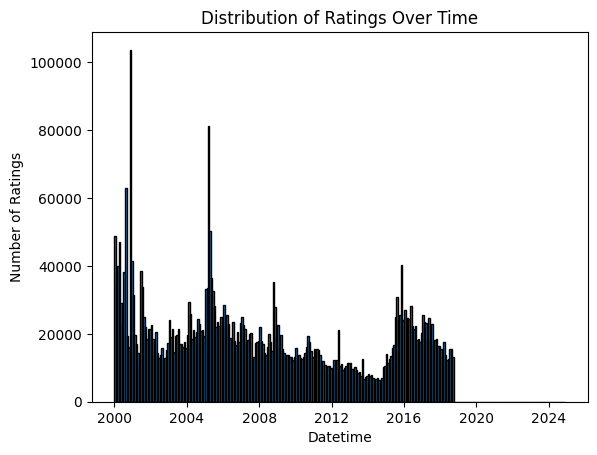

In [7]:
from datetime import datetime

rating_df = pd.read_csv(Config.RATINGS_PATH)

# parse datetime from timestamp
rating_df['datetime'] = pd.to_datetime(rating_df[Config.TIMESTAMP_COL], unit='s')
rating_df = rating_df.sort_values(by='datetime', ascending=False)
display(rating_df.describe())

# distribution of ratings
rating_df = rating_df[rating_df['datetime'] > '2000-01-01']  # filter out ratings before 2000
rating_counts = rating_df['datetime'].value_counts().sort_index()
bins = [datetime(year, month, 1) for year in range(2000, 2025) for month in range(1, 13)]
plt.hist(rating_df['datetime'], bins=bins, edgecolor='black')
plt.title("Distribution of Ratings Over Time")
plt.xlabel("Datetime")
plt.ylabel("Number of Ratings")
plt.show()

# display(f"Min Timestamp: {datetime.fromtimestamp(min_timestamp)} | Max Timestamp: {datetime.fromtimestamp(max_timestamp)}")

In [8]:
# A. Khởi tạo đường dẫn động (Version bằng Timestamp)
dir_path_with_timestamp: Path =  Config.CF_DIR / Config.RUN_TIMESTAMP
os.makedirs(dir_path_with_timestamp, exist_ok=True)
model_path: Path = dir_path_with_timestamp / f"{Config.RUN_TIMESTAMP}_cf_model.pth"
mapping_path: Path = dir_path_with_timestamp / f"{Config.RUN_TIMESTAMP}_mappings.parquet"
metrics_path: Path = dir_path_with_timestamp / f"{Config.RUN_TIMESTAMP}_metrics.json"
history_plot_path: Path = dir_path_with_timestamp / f"{Config.RUN_TIMESTAMP}_history_loss_chart.png"
lost_plot_path: Path = dir_path_with_timestamp / f"{Config.RUN_TIMESTAMP}_loss_chart.png"


# B. Xử lý & Chia tập Dữ liệu
preprocessor = DataPreprocessor(
    csv_path=Config.RATINGS_PATH,
    user_col=Config.USER_COL,
    movie_col=Config.MOVIE_COL,
    rating_col=Config.RATING_COL,
    timestamp_col=Config.TIMESTAMP_COL,
    max_rows=Config.MAX_ROWS_TO_PROCESS,
    chunk_size=Config.CHUNK_SIZE,
    train_ratio=Config.TRAIN_RATIO,
    val_ratio=Config.VAL_RATIO,
    test_ratio=Config.TEST_RATIO,
    num_test_per_user=5,
    num_val_per_user=0,
    parquet_dir=Config.PARQUET_DIR
)
user_mapping, movie_mapping = preprocessor.process_and_split()

# Lưu Mapping
users_df = pd.DataFrame(list(user_mapping.items()), columns=['id', 'idx'])
users_df['type'] = 'user'
movies_df = pd.DataFrame(list(movie_mapping.items()), columns=['id', 'idx'])
movies_df['type'] = 'movie'
pd.concat([users_df, movies_df], ignore_index=True).to_parquet(mapping_path, engine='pyarrow', index=False)

# # C. Khởi tạo DataLoader
# train_ds = LazyParquetDataset(glob.glob(f"{Config.PARQUET_DIR}/train/*.parquet"), Config.BATCH_SIZE, Config.RATING_COL)
# val_ds = LazyParquetDataset(glob.glob(f"{Config.PARQUET_DIR}/val/*.parquet"), Config.BATCH_SIZE, Config.RATING_COL)

# train_loader = DataLoader(train_ds, batch_size=None)
# val_loader = DataLoader(val_ds, batch_size=None)

# # D. Khởi tạo Model & Training
# model = CollaborativeFilteringModel(
#     len(user_mapping), 
#     len(movie_mapping), 
#     Config.EMBEDDING_DIM, 
#     Config.INIT_STD)
# trainer = ModelTrainer(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=Config.DEVICE,
#     learning_rate=Config.LEARNING_RATE,
#     weight_decay=Config.WEIGHT_DECAY,
#     epochs=Config.EPOCHS,
#     save_model_path=model_path,
#     save_metrics_path=metrics_path
# )

# history = trainer.train()

# E. Hiển thị Biểu đồ Loss
# ResultVisualizer.plot_history(history, history_plot_path)


[INFO] Đang tìm Top K tương tác mới nhất (Sort theo Timestamp)...
[INFO] Đã trích xuất 5000000 dòng tương tác mới nhất.
[INFO] Đã chia tập thành công. Train: 4616650 | Val: 0 | Test: 383350


## 7. Đánh giá Tập Test & Thử nghiệm Client (Evaluation)


In [9]:
# plot MSE, RMSE, MAE, R2 Score trên tập Test
def plot_test_evaluation(all_ratings, all_preds):
    plt.figure(figsize=(10, 6))
    plt.scatter(all_ratings, all_preds, alpha=0.5)
    plt.plot([all_ratings.min(), all_ratings.max()], [all_ratings.min(), all_ratings.max()], 'r--', lw=2)
    plt.title('Actual vs Predicted Ratings')
    plt.xlabel('Actual Ratings')
    plt.ylabel('Predicted Ratings')
    plt.grid(True)
    plt.show()

In [10]:
# A. Test Set Evaluation
test_ds = LazyParquetDataset(glob.glob(f"{Config.PARQUET_DIR}/test/*.parquet"), Config.BATCH_SIZE, Config.RATING_COL)
test_loader = DataLoader(test_ds, batch_size=None)

# mse, test_metrics, all_preds, all_ratings = trainer.evaluate(test_loader, criterion=nn.MSELoss(), mode="test")
# plot_test_evaluation(all_ratings, all_preds)

# B. Thử nghiệm Client với Model vừa train
# client = RecommendationClient(model_path, mapping_path, len(user_mapping), len(movie_mapping), Config.EMBEDDING_DIM, Config.INIT_STD, Config.DEVICE)



## ALS model

In [11]:
# !pip install implicit

In [12]:
import implicit
from scipy.sparse import csr_matrix

train_df = pd.read_parquet(f"{Config.PARQUET_DIR}/train/data.parquet")
scores = train_df[Config.RATING_COL].values
user_idx = train_df["user_idx"].values
movie_idx = train_df["movie_idx"].values
# 1. Build ma trận sparse: hàng=user, cột=movie, giá trị=score (confidence)
# Đọc số lượng users/movies thực tế từ mapping để set kích thước cứng cho ma trận
mapping_df = pd.read_parquet(mapping_path)
num_users = len(mapping_df[mapping_df["type"] == "user"])
num_movies = len(mapping_df[mapping_df["type"] == "movie"])
matrix = csr_matrix((scores, (user_idx, movie_idx)), shape=(num_users, num_movies))

# 2. Train — KHÔNG có vòng lặp epoch/batch/optimizer.step() thủ công như PyTorch
model = implicit.als.AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=20
)
model.fit(matrix)   # toàn bộ việc "luân phiên giải" nằm gọn trong 1 dòng này


c:\Users\THUYEN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\THUYEN\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:25<00:00,  1.28s/it]


In [13]:
# 3. Dùng
user_id = 5
recommendations = model.recommend(user_id, matrix[user_id], N=10)
user_vectors = model.user_factors   # lấy vector nếu cần
movie_vectors = model.item_factors

# display(recommendations)
# display(user_vectors)
# display(movie_vectors)


for i in range(5):
    user_id = np.random.choice(list(user_idx))
    print(f"User ID: {user_id}")
    # recommendations = client.recommend(user_id=user_id, top_k=5)
    # movie_ids = [rec['movieId'] for rec in recommendations]
    # scores = [rec['score'] for rec in recommendations]
    # recommendation = (movie_ids, scores)
    # print(f"Recommendations by SGD")
    # print(recommendation)
    
    print(f"Recommendations by Implicit")
    recommendations_implicit = model.recommend(user_id, matrix[user_id], N=5)
    display(recommendations_implicit)

User ID: 44913
Recommendations by Implicit


(array([252,  30, 220,  53, 196], dtype=int32),
 array([0.85509706, 0.8422789 , 0.83525956, 0.8314512 , 0.8182298 ],
       dtype=float32))

User ID: 41611
Recommendations by Implicit


(array([199, 351, 722, 225,  50], dtype=int32),
 array([1.1619399, 1.075424 , 1.0653809, 1.0130038, 1.0012287],
       dtype=float32))

User ID: 147101
Recommendations by Implicit


(array([303, 351, 285, 361, 348], dtype=int32),
 array([0.8521483 , 0.78151095, 0.7685733 , 0.7493504 , 0.7276622 ],
       dtype=float32))

User ID: 53404
Recommendations by Implicit


(array([ 77, 345, 179, 365, 295], dtype=int32),
 array([0.7924035 , 0.74969554, 0.6453231 , 0.59649944, 0.5233014 ],
       dtype=float32))

User ID: 7012
Recommendations by Implicit


(array([468, 291,  43, 387,  96], dtype=int32),
 array([1.2539194 , 1.0622919 , 1.0233587 , 0.9907714 , 0.96690637],
       dtype=float32))

## Build Test

In [14]:

class Evaluation:
    
    @staticmethod
    def evaluate_all(model, matrix,test_df, k: int = 10) -> dict:
        user_ids = test_df["user_idx"].unique()
        rows = []
        for user_id in user_ids:
            relevant_ids = set(test_df[test_df["user_idx"] == user_id]["movie_idx"].values)
            recommended_ids, scores = model.recommend(user_id, matrix[user_id], N=k)
            precision, recall = Evaluation.precision_recall_at_k(recommended_ids, relevant_ids, k)
            ndcg = Evaluation.ndcg_at_k(recommended_ids, relevant_ids, k)
            f1 = Evaluation.f1_at_k(precision, recall)
            hit_rate = Evaluation.hit_rate_at_k(recommended_ids, relevant_ids, k)
            rows.append({
                "user_id": user_id,
                "precision@k": precision,
                "recall@k": recall,
                "ndcg@k": ndcg,
                "f1@k": f1,
                "hit_rate@k": hit_rate
            })
            
        return {
            "precision@k": np.mean([r["precision@k"] for r in rows]),
            "recall@k": np.mean([r["recall@k"] for r in rows]),
            "ndcg@k": np.mean([r["ndcg@k"] for r in rows]),
            "f1@k": np.mean([r["f1@k"] for r in rows]),
            "hit_rate@k": np.mean([r["hit_rate@k"] for r in rows]),
        }
    
    @staticmethod
    def ndcg_at_k(recommended_ids: list, relevant_ids: set, k: int) -> float:
        # DCG: cộng dồn, phim đúng càng ở vị trí đầu càng được tính điểm cao
        dcg = sum(
            1.0 / np.log2(rank + 2)           # rank bắt đầu từ 0 -> log2(2), log2(3)...
            for rank, movie_id in enumerate(recommended_ids[:k])
            if movie_id in relevant_ids
        )
        # IDCG: trường hợp LÝ TƯỞNG — toàn bộ phim đúng nằm NGAY ĐẦU danh sách
        ideal_hits = min(len(relevant_ids), k)
        idcg = sum(1.0 / np.log2(rank + 2) for rank in range(ideal_hits))
        return dcg / idcg if idcg > 0 else 0.0
    
    @staticmethod
    def precision_recall_at_k(recommended_ids: list, true_id: int, k):
        # recommended_ids: list movie_id model gợi ý (top-K)
        # true_id: movie_id THẬT user đã tương tác (bị giấu lúc train)
        
        hit = 1 if true_id in recommended_ids[:k] else 0
        #     ^^^ đây chính là bước "check movie_id có nằm trong top-K không"
        #     KHÔNG kiểm tra score, chỉ kiểm tra ID có TRÙNG hay không
        
        return hit / k, hit

    @staticmethod
    def precision_recall_at_k(recommended_ids: list, true_ids: list, k):
        # true_ids giờ là 1 SET nhiều movie_id (vd 5 phim bị giấu)
        recommended_set = set(recommended_ids[:k])
        true_set = set(true_ids)
        
        hits = len(recommended_set & true_set)   # ĐẾM số ID TRÙNG giữa 2 tập
        
        precision = hits / k                      # hits / K
        recall = hits / len(true_set)              # hits / tổng số ground truth
        return precision, recall

    @staticmethod
    def f1_at_k(precision, recall):
        if precision + recall == 0:
            return 0.0
        return 2 * precision * recall / (precision + recall)

    @staticmethod
    def hit_rate_at_k(recommended_ids, relevant_ids, k):
        return 1.0 if set(recommended_ids[:k]) & relevant_ids else 0.0

In [15]:
test_df = pd.read_parquet(Config.PARQUET_DIR / "test" / "data.parquet")
display(test_df.info())

eval = Evaluation.evaluate_all(model, matrix, test_df, k=5)


<class 'pandas.DataFrame'>
RangeIndex: 383350 entries, 0 to 383349
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     383350 non-null  int64  
 1   movieId    383350 non-null  int64  
 2   rating     383350 non-null  float64
 3   timestamp  383350 non-null  int64  
 4   user_idx   383350 non-null  int64  
 5   movie_idx  383350 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 17.5 MB


None

In [16]:
display(eval)


{'precision@k': np.float64(0.08124951089083082),
 'recall@k': np.float64(0.08124951089083082),
 'ndcg@k': np.float64(0.08575869743782238),
 'f1@k': np.float64(0.08124951089083084),
 'hit_rate@k': np.float64(0.3315247163166819)}